# Import Packages

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTENC, SMOTE
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from itertools import product

# Set Constants

In [51]:
SEED = 6740

# Read-In Data

In [52]:
thyroid_df = pd.read_csv("Thyroid-Dataset.csv")
thyroid_df.info()
thyroid_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9171 entries, 0 to 9170
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        9171 non-null   int64  
 1   sex                        8864 non-null   object 
 2   on thyroxine               9171 non-null   bool   
 3   query on thyroxine         9171 non-null   bool   
 4   on antithyroid medication  9171 non-null   bool   
 5   sick                       9171 non-null   bool   
 6   pregnant                   9171 non-null   bool   
 7   thyroid surgery            9171 non-null   bool   
 8   I131 treatment             9171 non-null   bool   
 9   query hypothyroid          9171 non-null   bool   
 10  query hyperthyroid         9171 non-null   bool   
 11  lithium                    9171 non-null   bool   
 12  goitre                     9171 non-null   bool   
 13  tumor                      9171 non-null   bool 

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,referral source,class
0,29,F,False,False,False,False,False,False,False,False,...,False,False,False,1.6,1.9,128.0,NaN,NaN,other,negative
1,41,F,False,False,False,False,False,False,False,False,...,False,False,False,NaN,NaN,NaN,NaN,NaN,other,negative
2,36,F,False,False,False,False,False,False,False,False,...,False,False,False,NaN,NaN,NaN,NaN,NaN,other,negative
3,32,F,False,False,False,False,False,False,False,False,...,False,False,False,NaN,NaN,NaN,NaN,NaN,other,miscellaneous
4,60,F,False,False,False,False,False,False,False,False,...,False,False,False,NaN,NaN,NaN,NaN,NaN,other,negative


# Data Exploration

## Numerical Features

FTI = TT4 X T3. We have both of those values so we should drop it from our dataset.

In [53]:
num_cols = ['age', 'TSH', 'T3', 'TT4', 'T4U']

### Boxplots
While all of the variables have a considerable number of outliers, there are clear errors in the age data that must be fixed. There are very few rows with this issue, so they were simply dropped.

In [54]:
thyroid_df[thyroid_df['age'] > 150]

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,referral source,class
2975,455,F,False,False,False,False,False,False,False,False,...,False,False,False,1.10,2.0,118.0,1.13,104.0,SVI,negative
5709,65511,M,False,False,False,False,False,False,False,False,...,False,False,False,0.38,2.0,113.0,1.08,104.0,other,negative
6391,65512,M,False,False,False,False,False,False,False,False,...,False,False,False,0.03,2.8,112.0,0.84,133.0,other,negative
8104,65526,F,False,False,False,False,False,False,False,False,...,False,False,False,1.50,NaN,132.0,1.02,129.0,other,negative


In [55]:
thyroid_df = thyroid_df[thyroid_df['age'] < 150]
thyroid_df.reset_index(drop=True, inplace=True)

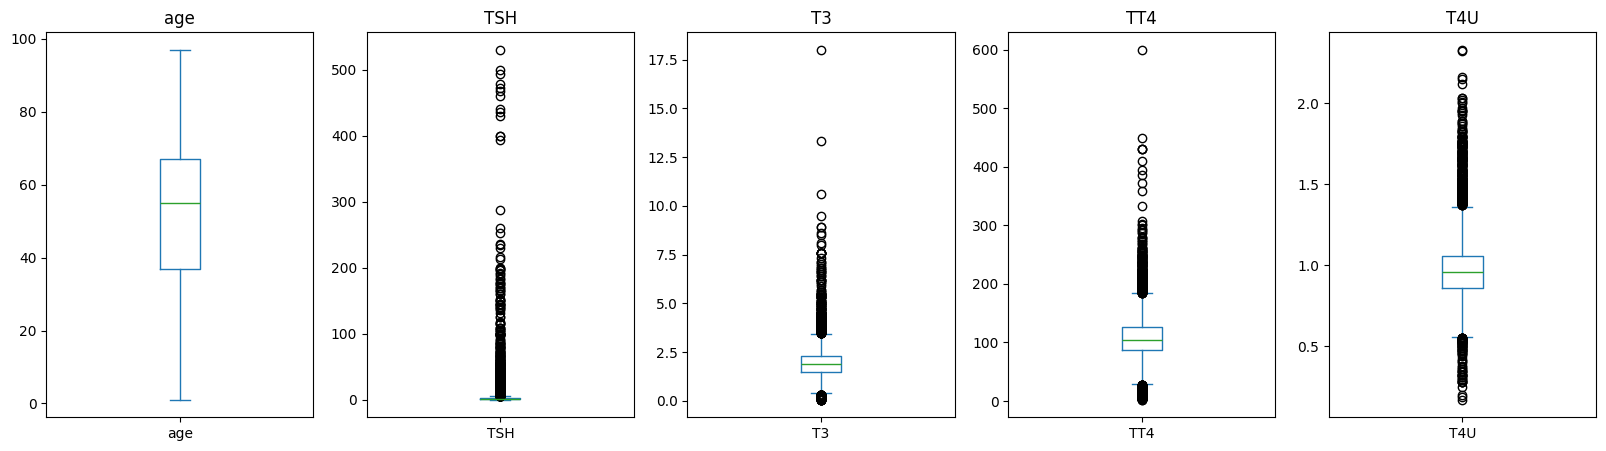

In [56]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in  enumerate(num_cols):
    thyroid_df.plot(kind='box', y=col, ax=axes[i])
    axes[i].set_title(col)



### Scatterplot Matrix

Age does not seem to correlate with any variable.

TSH, T3, and TT4 seem quite right skewed and have nonlinear relationships with the other blood test results.

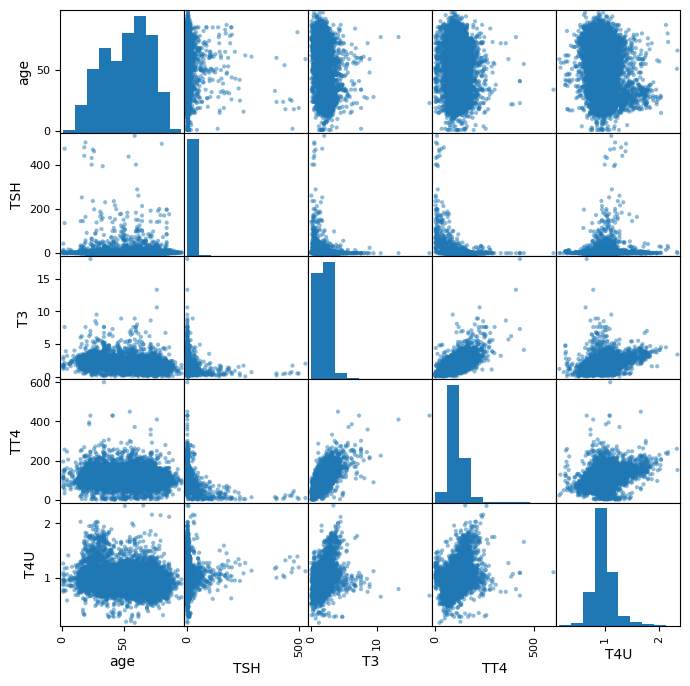

In [57]:
pd.plotting.scatter_matrix(thyroid_df[num_cols], figsize=(8, 8))
plt.show()

### Transforms

For TSH and T3 the log transform seems to do well, while for TT4 the square root transform does better.

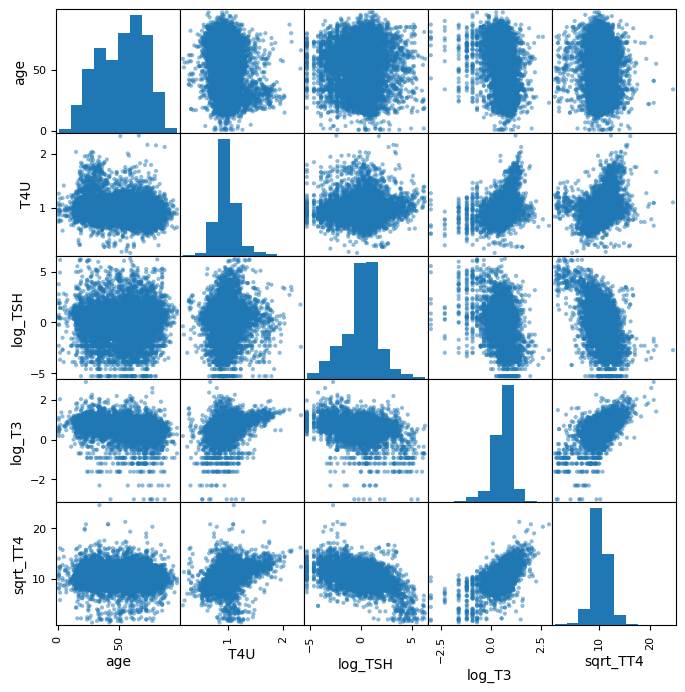

In [58]:
thyroid_df['log_TSH'] = np.log(thyroid_df['TSH'])
thyroid_df['log_T3'] = np.log(thyroid_df['T3'])
thyroid_df['sqrt_TT4'] = np.sqrt(thyroid_df['TT4'])
num_cols.extend(['log_TSH', 'log_T3', 'sqrt_TT4'])
num_cols.remove('TSH')
num_cols.remove('T3')
num_cols.remove('TT4')
pd.plotting.scatter_matrix(thyroid_df[num_cols], figsize=(8, 8))
plt.show()

### Correlation Heatmap

There is low correlation between all of the newly transformed numerical variables.

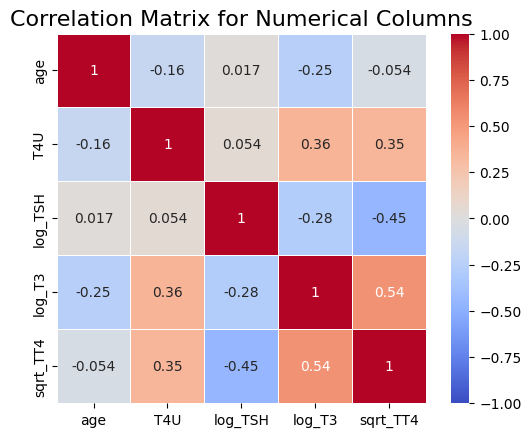

In [59]:
sns.heatmap(thyroid_df[num_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Correlation Matrix for Numerical Columns', fontsize=16)
plt.show()

## Discrete Features

In [60]:
bool_cols = thyroid_df.dtypes[thyroid_df.dtypes == 'bool'].index.to_list()
cat_cols = thyroid_df.dtypes[thyroid_df.dtypes == 'object'].index.to_list()
cat_cols.remove('class')
disc_cols = bool_cols + cat_cols

### Bar Charts

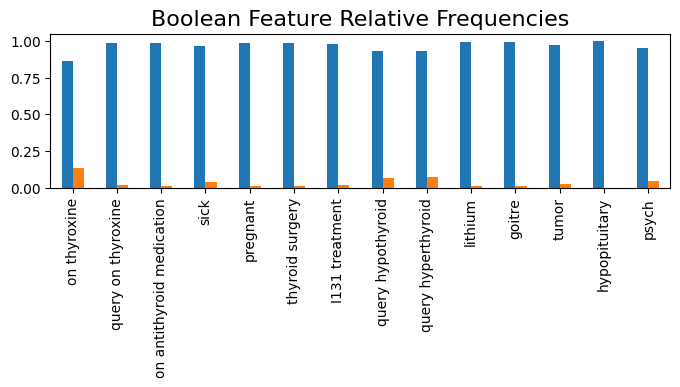

In [61]:
thyroid_df[bool_cols].apply(lambda x: x.value_counts(normalize=True)).transpose().plot(kind='bar', figsize=(8, 2), legend=False)
plt.title('Boolean Feature Relative Frequencies', fontsize=16)
plt.show()

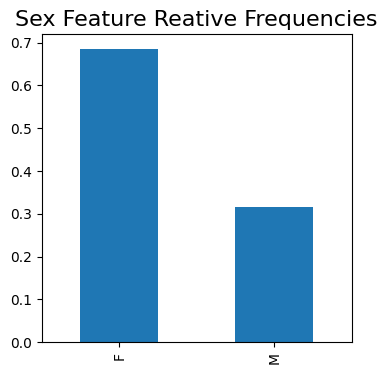

In [62]:
thyroid_df['sex'].value_counts(normalize=True).plot(kind='bar', figsize=(4, 4))
plt.xlabel('')
plt.title('Sex Feature Reative Frequencies', fontsize=16)
plt.show()

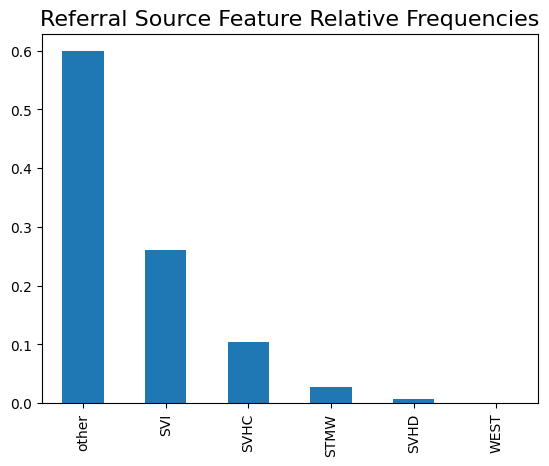

In [63]:
thyroid_df['referral source'].value_counts(normalize=True).plot(kind='bar')
plt.xlabel('')
plt.title('Referral Source Feature Relative Frequencies', fontsize=16)
plt.show()

### Calculate Mutual Information Between Features

The features do not seem very correlated. The mutual pairwise mutual information scores are low.

In [64]:
ohe = OneHotEncoder()
encoded_cols = ohe.fit_transform(thyroid_df[cat_cols]).toarray()
disc_df = pd.concat([thyroid_df[bool_cols], 
                        pd.DataFrame(encoded_cols, columns=ohe.get_feature_names_out(cat_cols))], axis=1)

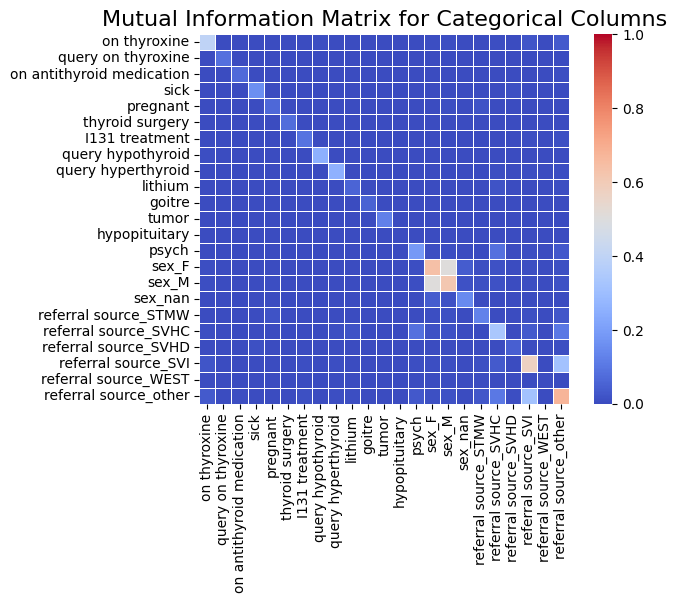

In [65]:
mi_array = []
cols = disc_df.columns.to_list()
for col1, col2 in product(cols, repeat=2):
    mi = mutual_info_classif(disc_df[col1].to_frame(), np.array(disc_df[col2]), discrete_features=True)
    mi_array.append(mi)
mi_array = np.array(mi_array).reshape(len(cols), len(cols))
sns.heatmap(mi_array, xticklabels=cols, yticklabels=cols, cmap='coolwarm', vmin=0, vmax=1, linewidths=0.5, square=True)
plt.title('Mutual Information Matrix for Categorical Columns', fontsize=16)
plt.show()

## Class Labels

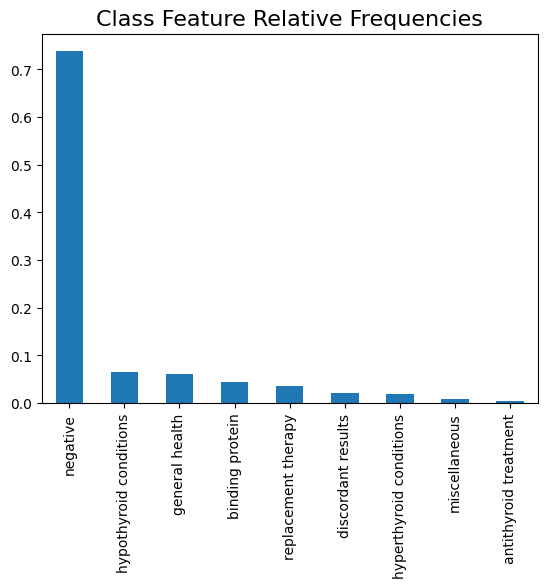

In [66]:
thyroid_df['class'].value_counts(normalize=True).plot(kind='bar')
plt.title('Class Feature Relative Frequencies', fontsize=16)
plt.xlabel('')
plt.show()

# Data Cleaning

Already removed the age errors.

## Add missing data flags

In [67]:
missing_data_cols = ['sex', 'TSH', 'T3', 'TT4', 'T4U']
for col in missing_data_cols:
    new_col_name = col + '_missing'
    thyroid_df[new_col_name] = thyroid_df[col].isna()

## Encode Discete Features

In [68]:
thyroid_df['sex'] = thyroid_df['sex'].map({'F': 0, 'M': 1}).astype('Int64')
bool_cols = thyroid_df.dtypes[thyroid_df.dtypes == 'bool'].index
for col in bool_cols:
    thyroid_df[col] = thyroid_df[col].map({True: 1, False: 0}).astype('int64')

## Encode Class Labels

In [69]:
thyroid_df['label'] = 0
thyroid_df['label'] += thyroid_df['class'] == 'hypothyroid conditions'
thyroid_df['label'] += 2 * (thyroid_df['class'] == 'hyperthyroid conditions')

## Build Cleaned Dataset

Use transformed numerical variables

Use encoded discrete variables and labels

In [70]:
cleaned_df = thyroid_df.copy()
cleaned_df = cleaned_df.drop(columns=['class', 'referral source', 'TSH', 'T3', 'TT4', 'FTI'])
cleaned_df['sex'] = cleaned_df['sex'].astype('float64')

# Test Train Split

In [71]:
X = cleaned_df.drop(columns='label')
y = cleaned_df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

# Feature Selection

Calculate mutual information for SMOTEENN resampled data in order to make sure to detect features important to the minority classes.

In [72]:
def make_feature_selection_pipeline():
    num_cols = ['age', 'T4U', 'log_TSH', 'log_T3', 'sqrt_TT4']
    cat_imp_cols = ['sex']
    cat_inds = list(range(5, len(X_train.columns)))

    pipe_num_cols = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler())
    ])

    pipe_cat_imp_cols = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num_imp_scale', pipe_num_cols, num_cols),
            ('cat_imp', pipe_cat_imp_cols, cat_imp_cols),
        ],
        remainder='passthrough'
    )    

    smotenc = SMOTENC(categorical_features=cat_inds, random_state=SEED)
    smote_enn = SMOTEENN(random_state=SEED, smote=smotenc)

    steps = [
        ('preprocessor', preprocessor),
        ('resampler', smote_enn)
        ]

    return Pipeline(steps)

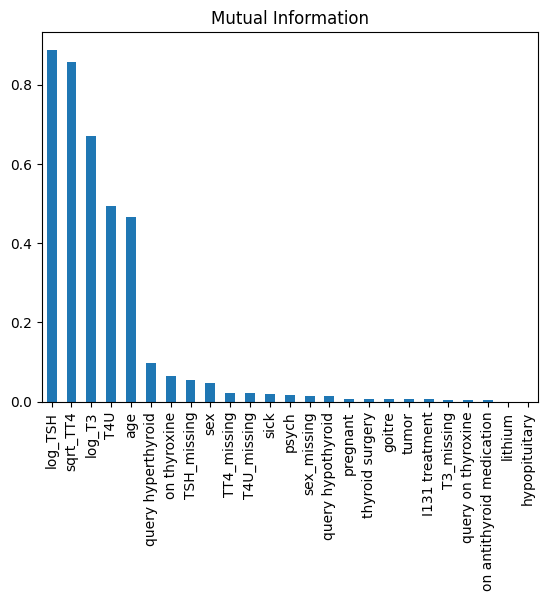

In [73]:
pipe = make_feature_selection_pipeline()
X_resample, y_resample = pipe.fit_resample(X_train, y_train)
index = [name.split('__')[1] for name in pipe.get_feature_names_out(X_train.columns)]
mi = mutual_info_classif(X_resample, y_resample)
mi = pd.DataFrame(mi, index=index, columns=['MI']).sort_values(by='MI', ascending=False) 
mi.plot(kind='bar', legend=False, title='Mutual Information')
plt.xlabel('')
plt.show()

In [74]:
X_train_selected = X_train[mi.index.to_list()[:5]].reset_index(drop=True)
X_test_selected = X_test[mi.index.to_list()[:5]].reset_index(drop=True)

# Classifier Pipeline Function Builder

Impute, Scale, Resample, Estimator Placeholder

In [75]:
def make_pipeline(estimator, estimator_name):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),
        ('resampler', SMOTEENN(random_state=SEED)),
        (estimator_name, estimator)
    ])

# Classifiers

## Define Scorer for CV

In [76]:
def score(y_true, y_pred):
    return np.array(f1_score(y_true, y_pred, average=None)).min()

scorer = make_scorer(score)

## Logistic Regression

## K-Nearest Neighbors

## Support Vector Machine

## Random Forest

### Find Optimal Num Trees

In [78]:
num_trees = np.array(range(25, 151, 25))
max_depth = np.array(range(10, 41, 5))
param_grid = {'rf__n_estimators': num_trees, 'rf__max_depth': max_depth}
pipe = make_pipeline(RandomForestClassifier(random_state=SEED), 'rf')
rf = GridSearchCV(pipe, param_grid, cv=5, scoring=scorer)
rf = rf.fit(X_train_selected, y_train)

Best Score: 0.5522 (max depth: 20 num trees: 75)


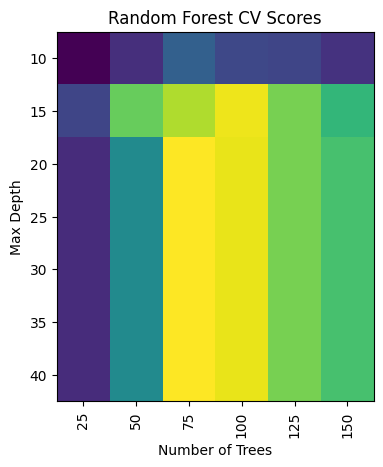

In [79]:
print(f'Best Score: {rf.best_score_:.4f} (max depth: {rf.best_params_['rf__max_depth']} num trees: {rf.best_params_["rf__n_estimators"]})') 

plt.imshow(rf.cv_results_['mean_test_score'].reshape(len(max_depth), len(num_trees)))
plt.xticks(np.arange(len(num_trees)), [str(n) for n in num_trees], rotation=90)
plt.xlabel('Number of Trees')
plt.yticks(np.arange(len(max_depth)), [str(n) for n in max_depth])
plt.ylabel('Max Depth')
plt.title('Random Forest CV Scores')
plt.show()

              precision    recall  f1-score   support

           0       1.00      0.95      0.97      1679
           1       0.73      0.99      0.84       119
           2       0.42      0.94      0.58        36

    accuracy                           0.95      1834
   macro avg       0.72      0.96      0.80      1834
weighted avg       0.97      0.95      0.96      1834



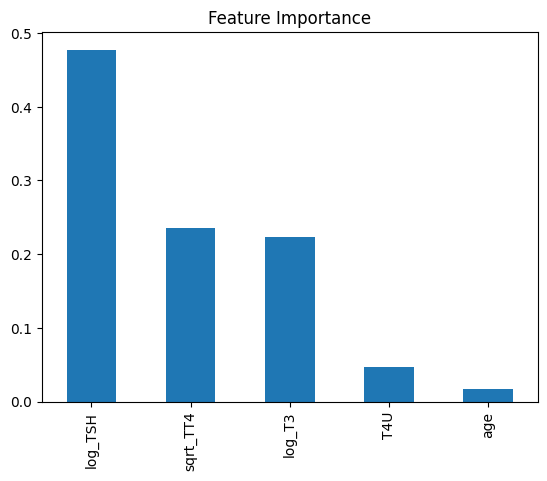

In [80]:
print(classification_report(y_test, rf.best_estimator_.predict(X_test_selected)))
feature_names = X_train_selected.columns
feature_importance = rf.best_estimator_['rf'].feature_importances_
feature_importance_df = pd.DataFrame({'feature_importance': feature_importance, 'feature_name': feature_names}).sort_values(by='feature_importance', ascending=False)
feature_importance_df.plot(kind='bar', x='feature_name', y='feature_importance', legend=False, title='Feature Importance')
plt.xlabel('')
plt.show()